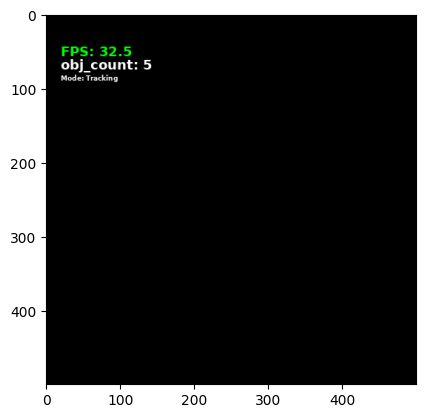

In [112]:
from halib import *
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from typing import Dict, Any, Optional, Tuple, List


class OSDRenderer:
    # Cache fonts class-wide to prevent lag from reloading .ttf files every frame
    _font_cache: Dict[Tuple[str, int], ImageFont.FreeTypeFont] = {}

    @classmethod
    def _get_pil_font(cls, font_path: str, size: int):
        """Loads and caches the font."""
        key = (font_path, size)
        if key not in cls._font_cache:
            try:
                cls._font_cache[key] = ImageFont.truetype(font_path, size)
            except IOError:
                # Fallback to default if path is wrong (looks ugly but prevents crash)
                print(f"Warning: Font not found at {font_path}, using default.")
                cls._font_cache[key] = ImageFont.load_default()  # ty:ignore[invalid-assignment]
        return cls._font_cache[key]

    @classmethod
    def draw_osd_pil(
        cls,
        frame: np.ndarray,
        data: Dict[str, Any],
        config: Optional[Dict[str, Any]] = None,
        pos: Tuple[int, int] = (10, 30),
        bg_opacity: float = 0.5,
        padding: int = 10,
        line_spacing: int = 5,
        font_path: str = "arial.ttf",  # Path to your .ttf file
        base_font_size: int = 16,  # Base size in pixels
    ) -> np.ndarray:
        """
        Draws multi-line OSD using PIL for high-quality text rendering.
        """
        # 0. Basic Setup
        if not data:
            return frame

        config = config or {}
        x_start, y_start = pos

        # Convert to PIL Image (BGR -> RGB)
        img_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        draw = ImageDraw.Draw(img_pil, "RGBA")

        # 1. Prepare & Measure Lines
        measured_lines = []
        max_w = 0
        total_h = 0

        for key, value in data.items():
            # Get config for this key
            item_conf = config.get(key, {})

            # Text content
            label = item_conf.get("label", key)
            text_str = f"{label}: {value}"

            # Appearance
            # Note: PIL uses RGB, OpenCV config usually provides BGR. We swap below.
            color_bgr = item_conf.get("color", (255, 255, 255))
            font_size = item_conf.get("size", base_font_size)

            # Load Font
            font = cls._get_pil_font(font_path, font_size)

            # Measure Text (bbox returns: left, top, right, bottom)
            bbox = draw.textbbox((0, 0), text_str, font=font)
            w = bbox[2] - bbox[0]
            h = bbox[3] - bbox[1]  # Height of the text itself

            line_h = h + line_spacing  # Row height

            measured_lines.append(
                {
                    "text": text_str,
                    "font": font,
                    "color_bgr": color_bgr,
                    "w": w,
                    "h": h,
                    "row_h": line_h,
                }
            )

            max_w = max(max_w, w)
            total_h += line_h

        if not measured_lines:
            return frame

        # Remove extra spacing from the last line for tighter box fitting
        total_h -= line_spacing

        box_w = max_w + 2 * padding
        box_h = total_h + 2 * padding

        # 2. Draw Background (Using PIL Alpha Composite)
        if bg_opacity > 0:
            # Define rectangle coordinates (x0, y0, x1, y1)
            rect_coords = (x_start, y_start, x_start + box_w, y_start + box_h)

            # Draw semi-transparent black box
            # Fill color: (R, G, B, Alpha) -> (0, 0, 0, int(255 * opacity))
            alpha_val = int(255 * bg_opacity)
            draw.rectangle(rect_coords, fill=(0, 0, 0, alpha_val))

        # 3. Draw Text
        curr_y = y_start + padding

        for line in measured_lines:
            # Handle Color: BGR -> RGB
            c = line["color_bgr"]
            rgb_color = (c[2], c[1], c[0])

            # Draw text
            # PIL draws from Top-Left, unlike OpenCV's Bottom-Left
            draw.text(
                (x_start + padding, curr_y),
                line["text"],
                font=line["font"],
                fill=rgb_color,
            )

            curr_y += line["row_h"]

        # 4. Convert back to OpenCV (RGB -> BGR)
        return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)


# Dummy Data
data = {"fps": 32.5, "obj_count": 5, "status": "Tracking"}

# Config (Optional)
config = {
    "fps": {"label": "FPS", "color": (0, 255, 0)},  # Green (BGR)
    "status": {"label": "Mode", "size": 9},  # Red (BGR)
}

# Use a real font path (e.g., Arial or Roboto)
# On Linux: "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"
# On Windows: "C:/Windows/Fonts/arial.ttf"
font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"
img = np.zeros((500, 500, 3), dtype=np.uint8)

frame = OSDRenderer.draw_osd_pil(
    img, data, config, font_path=font_path, base_font_size=18, bg_opacity=0.6
)
plt.imshow(frame)

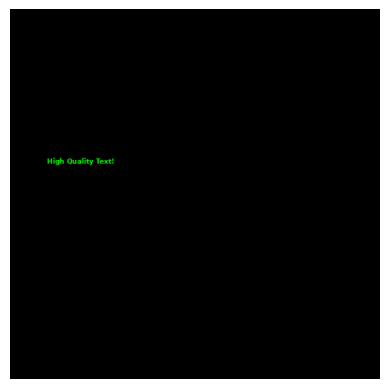

In [97]:
from halib import *
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont


def put_text_pil(img, text, position, font_path, size, color):
    """
    Draws high-quality text using PIL and converts back to OpenCV.

    Args:
        img: The OpenCV image (numpy array).
        text: The text string to draw.
        position: (x, y) tuple.
        font_path: Path to a .ttf file (e.g., "arial.ttf").
        size: Font size in integers.
        color: (B, G, R) tuple (OpenCV format).
    """

    # 1. Convert OpenCV (BGR) to PIL (RGB)
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    # 2. Setup Drawing
    draw = ImageDraw.Draw(img_pil)

    # Load font (fallback to default if file not found)
    try:
        font = ImageFont.truetype(font_path, size)
    except IOError:
        print(f"Font not found: {font_path}, using default.")
        font = ImageFont.load_default()

    # 3. Draw Text (PIL uses RGB color)
    # Convert OpenCV BGR color to RGB for PIL
    rgb_color = (color[2], color[1], color[0])
    draw.text(position, text, font=font, fill=rgb_color)

    # 4. Convert back to OpenCV (BGR)
    img_out = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

    return img_out


# --- Usage Example ---
img = np.zeros((500, 500, 3), dtype=np.uint8)

# Windows font path example (Update for Linux/Mac)
# Linux: "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"
# Mac: "/Library/Fonts/Arial.ttf"
# font_path = "C:/Windows/Fonts/arial.ttf"
font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"

img = put_text_pil(img, "High Quality Text!", (50, 200), font_path, 9, (0, 255, 0))

plt.imshow(img)
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

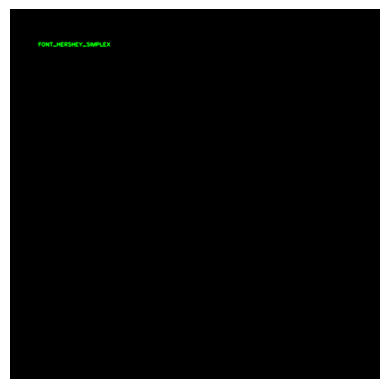

In [79]:
import cv2
from halib import *

# create a np image size 400x400 with 3 channels
img = np.zeros((400, 400, 3), dtype=np.uint8)
img = cv2.putText(
    img,
    "FONT_HERSHEY_SIMPLEX",
    (30, 40),
    cv2.FONT_HERSHEY_PLAIN,
    0.4,
    (0, 255, 0),
    1,
    lineType=cv2.LINE_AA,
)

plt.imshow(img)
plt.axis("off")


In [ ]:
from halib import *
from src.config import Config

cfg = Config.from_custom_yaml_file("config/zruns/__base.yaml")
pprint(cfg)
pprint(cfg.cfg_name)
pprint(cfg.get_outdir())
cfg.save_to_outdir()

In [21]:
from halib import *

data = np.arange(48)
pprint(data)
H, W = 4, 12

block_h, block_w = 2, 4

rows, cols = H // block_h, W // block_w

pprint(f"{rows=}, {cols=}, {H=}, {W=}, {block_h=}, {block_w=}")

d1 = data.reshape(H, W)
pprint(d1)

d2 = data.reshape(rows, block_h, cols, block_w).swapaxes(1, 2)
pprint(d2)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
│      17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
│      34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47])

'rows=2, cols=3, H=4, W=12, block_h=2, block_w=4'

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
│      [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
│      [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35],
│      [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]])

array([[[[ 0,  1,  2,  3],
│   │    [12, 13, 14, 15]],
│   │   
│   │   [[ 4,  5,  6,  7],
│   │    [16, 17, 18, 19]],
│   │   
│   │   [[ 8,  9, 10, 11],
│   │    [20, 21, 22, 23]]],
│      
│      
│      [[[24, 25, 26, 27],
│   │    [36, 37, 38, 39]],
│   │   
│   │   [[28, 29, 30, 31],
│   │    [40, 41, 42, 43]],
│   │   
│   │   [[32, 33, 34, 35],
│   │    [44, 45, 46, 47]]]])